# Imported and install required libraries

In [1]:
# For Data Handling & System Utilities
import pandas as pd
import numpy as np
import random
import os

# For Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter, MaxNLocator
from IPython.display import Markdown, display
from IPython.display import display, HTML

# Statistical & Distribution Analysis
from scipy.stats import gamma
import missingno as msno

# Machine Learning (Data Splitting)
from sklearn.model_selection import train_test_split

In [2]:
# Machine Learning – Data Preparation
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Machine Learning – Models (Classification)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import ExtraTreesClassifier, RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC

# Model Evaluation Metrics
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve,
    precision_recall_curve, classification_report,
    confusion_matrix, ConfusionMatrixDisplay)

In [3]:
# !pip install yellowbrick
# Class Imbalance Handling & Resampling Techniques
from imblearn.over_sampling import SMOTE, ADASYN, RandomOverSampler   # Oversampling methods
from imblearn.under_sampling import TomekLinks                        # Undersampling method
from imblearn.combine import SMOTEENN                                 # Hybrid method (over + under)
from imblearn.pipeline import Pipeline                                # Pipeline for chaining resampling steps
from yellowbrick.target import ClassBalance

In [4]:
# For exporting ML model
import pickle

In [5]:
# For statistical calculation
from scipy import stats

In [6]:
import warnings
warnings.filterwarnings("ignore")

In [7]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

# Importing Preprocessed Train, Test and Holdout Dataset

In [8]:
# Define the directory where the data is stored
base_path = r"C:/Users/danie/Downloads/Data Analytic/credit_loan_analysis"

try:
    # Attempt to read the specific CSV files
    # We use os.path.join for path safety
    X_train = pd.read_csv(os.path.join(base_path, 'loan_inputs_train.csv'))
    y_train = pd.read_csv(os.path.join(base_path, 'loan_targets_train.csv'))
    X_test = pd.read_csv(os.path.join(base_path, 'loan_inputs_test.csv'))
    y_test = pd.read_csv(os.path.join(base_path, 'loan_targets_test.csv'))
    X_holdout = pd.read_csv(os.path.join(base_path, 'loan_inputs_holdout.csv'))
    y_holdout = pd.read_csv(os.path.join(base_path, 'loan_targets_holdout.csv'))
    
except FileNotFoundError:
    print(f"Error: Could not find the files in '{base_path}'.")
    print("Please verify the directory path and ensure the files were exported correctly.")
except Exception as e:
    print(f"An unexpected error occurred during import: {e}")

else:
    # Success confirmation and data verification
    print("Data successfully imported.")
    print(f"X_train shape: {X_train.shape}")
    print(f"y_train shape: {y_train.shape}")
    print(f"X_test shape: {X_test.shape}")
    print(f"y_test shape: {y_test.shape}")
    print(f"X_holdout shape: {X_holdout.shape}")
    print(f"y_holdout shape: {y_holdout.shape}")

Data successfully imported.
X_train shape: (240000, 9)
y_train shape: (240000, 1)
X_test shape: (80000, 9)
y_test shape: (80000, 1)
X_holdout shape: (80000, 9)
y_holdout shape: (80000, 1)


# Column to drop

In [9]:
# Define columns to remove
cols_to_drop = ['purpose', 'ead']

# Create a dictionary to iterate through splits and their names
splits = {'Training': X_train, 'Testing': X_test, 'Holdout': X_holdout}

print("🚀 Starting column removal...")

for name, df in splits.items():
    # Drop columns and update the dataframe in-place
    df.drop(columns=cols_to_drop, errors='ignore', inplace=True)
    
    # Verification: Check if columns still exist in the dataframe
    remaining_forbidden = [col for col in cols_to_drop if col in df.columns]
    
    if not remaining_forbidden:
        print(f"✅ {name} set: {cols_to_drop} successfully removed. (Remaining columns: {len(df.columns)})")
    else:
        print(f"❌ {name} set: Failed to remove {remaining_forbidden}")

# Final check
print(f"\nFinal Feature List (X_train): {X_train.columns.tolist()}")
print(f"\nFinal Feature List (X_test): {X_test.columns.tolist()}")
print(f"\nFinal Feature List (X_holdout): {X_holdout.columns.tolist()}")

🚀 Starting column removal...
✅ Training set: ['purpose', 'ead'] successfully removed. (Remaining columns: 7)
✅ Testing set: ['purpose', 'ead'] successfully removed. (Remaining columns: 7)
✅ Holdout set: ['purpose', 'ead'] successfully removed. (Remaining columns: 7)

Final Feature List (X_train): ['int_rate', 'interest_band', 'grade', 'loan_to_value', 'collateral', 'regularity_of_inflows', 'ltv_group']

Final Feature List (X_test): ['int_rate', 'interest_band', 'grade', 'loan_to_value', 'collateral', 'regularity_of_inflows', 'ltv_group']

Final Feature List (X_holdout): ['int_rate', 'interest_band', 'grade', 'loan_to_value', 'collateral', 'regularity_of_inflows', 'ltv_group']


# Re-inspecting the data

In [10]:
# Preview the first few rows to ensure data integrity for X_train
display(X_train.head())

,int_rate,interest_band,grade,loan_to_value,collateral,regularity_of_inflows,ltv_group
0,8.708671,7.5-9.5,B,0.695281,Yes,Yes,Moderate
1,11.854966,11.5-14.9,C,0.802834,Yes,Yes,High
2,11.365925,9.5-11.5,C,0.560825,Yes,Yes,Low
3,12.119646,11.5-14.9,C,0.915366,Yes,Yes,High
4,10.079624,9.5-11.5,B,0.451274,No,Yes,Low


In [11]:
# Preview the first few rows to ensure data integrity for y_train
display(y_train.head())

,default_status
0,0
1,0
2,0
3,0
4,0


In [12]:
# Proportion of default and non-default
counts = y_train.value_counts(normalize=True)
default_rate = counts.get(1, 0) * 100

print(f"Total Default Rate: {default_rate:.2f}%")
print(f"Total Non-Default Rate: {(100 - default_rate):.2f}%")

Total Default Rate: 9.52%
Total Non-Default Rate: 90.48%


In [13]:
# Combine training features (X_train) and target (y_train) into one trained dataset for reference
train_data = pd.concat([X_train, y_train], axis=1)

In [14]:
# Combine training features (X_train) and target (y_train) into one trained dataset for reference
test_data = pd.concat([X_test, y_test], axis=1)

In [15]:
# Combine training features (X_train) and target (y_train) into one trained dataset for reference
holdout_data = pd.concat([X_holdout, y_holdout], axis=1)

# Prevents dummy variable trap (perfect multicollinearity)

In [16]:
# Identify numerical and categorical columns
numerical_columns = X_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_columns = X_train.select_dtypes(include=["object", "category"]).columns.tolist()

# Count the number of columns in each list
num_numeric = len(numerical_columns)
num_categorical = len(categorical_columns)

# Preview the columns
print(f"Numeric data columns: {numerical_columns}")
print(f"Categorical data columns: {categorical_columns}")

# Display the counts
print(f"Number of Numeric columns: {num_numeric}")
print(f"Number of Categorical columns: {num_categorical}")
print(f"Total columns identified: {num_numeric + num_categorical}")

Numeric data columns: ['int_rate', 'loan_to_value']
Categorical data columns: ['interest_band', 'grade', 'collateral', 'regularity_of_inflows', 'ltv_group']
Number of Numeric columns: 2
Number of Categorical columns: 5
Total columns identified: 7


- "pd.get_dummies()" converts categorical columns (like 'interest_band', 'grade', 'collateral', etc.) into binary (0/1) columns.
- "drop_first=True" removes one category (becomes the baseline/reference) in a categorical column to avoid multicollinearity (the “dummy variable trap”). This is done separately on train, test and holdout sets.
- ".reindex(columns=...)". E.g. If the Test set has a category the Train set didn't have, it is dropped. If the Test set is missing a category the Train set had, it is added and filled with zeros.

In [17]:
# One-hot encode categorical variables
X_train_encoded = pd.get_dummies(X_train, columns=categorical_columns, drop_first=True)
X_test_encoded = pd.get_dummies(X_test, columns=categorical_columns, drop_first=True)
X_holdout_encoded = pd.get_dummies(X_holdout, columns=categorical_columns, drop_first=True)

# Align columns across Train, Test, AND Holdout to ensure consistency
# Alternatively: X_train_encoded, X_test_encoded = X_train_encoded.align(X_test_encoded, join='left', axis=1, fill_value=0)
X_train_cols = X_train_encoded.columns
X_test_encoded = X_test_encoded.reindex(columns=X_train_cols, fill_value=0)
X_holdout_encoded = X_holdout_encoded.reindex(columns=X_train_cols, fill_value=0)

In [18]:
# Shape and Column Alignment Check
def check_alignment(df_train, df_test, df_holdout):
    train_cols = set(df_train.columns)
    test_cols = set(df_test.columns)
    ho_cols = set(df_holdout.columns)
    
    is_aligned = (train_cols == test_cols == ho_cols)
    print(f"✅ All Columns Aligned: {is_aligned}")
    print(f"Shape - Train: {df_train.shape}, Test: {df_test.shape}, Holdout: {df_holdout.shape}")
    
    if not is_aligned:
        missing_test = train_cols - test_cols
        missing_ho = train_cols - ho_cols
        print(f"⚠️ Missing in Test: {missing_test}")
        print(f"⚠️ Missing in Holdout: {missing_ho}")

check_alignment(X_train_encoded, X_test_encoded, X_holdout_encoded)

✅ All Columns Aligned: True
Shape - Train: (240000, 12), Test: (80000, 12), Holdout: (80000, 12)


# Standardized data (Scaling)

Standardizes numerical features using:
$$z = \frac{x - \mu}{\sigma}$$

'scaler.fit_transform()' on training data:
- First learns the mean and standard deviation from the training data only.
- Then transforms (scales) the training data using those values. (Mean of 0 and STD of 1)

'scaler.transform()' on test data:
- The test data is scaled using the mean and standard deviation that were computed from the training set.
- The test set’s own statistics are never used.

In [19]:
# Standardize numerical features
# fit_transform on Train; transform only on Test and Holdout to prevent data leakage
scaler = StandardScaler()
X_train_encoded[numerical_columns] = scaler.fit_transform(X_train_encoded[numerical_columns])
X_test_encoded[numerical_columns] = scaler.transform(X_test_encoded[numerical_columns])
X_holdout_encoded[numerical_columns] = scaler.transform(X_holdout_encoded[numerical_columns])

In [20]:
# Check mean and std for a specific numerical feature across sets
feature_to_check = numerical_columns[0] # Pick the first one

scaling_audit = pd.DataFrame({
    'Metric': ['Mean', 'Std Dev'],
    'Train': [X_train_encoded[feature_to_check].mean(), X_train_encoded[feature_to_check].std()],
    'Test': [X_test_encoded[feature_to_check].mean(), X_test_encoded[feature_to_check].std()],
    'Holdout': [X_holdout_encoded[feature_to_check].mean(), X_holdout_encoded[feature_to_check].std()]
}).round(4)

print(f"🧪 Scaling Audit for: {feature_to_check}")
display(scaling_audit)

🧪 Scaling Audit for: int_rate


,Metric,Train,Test,Holdout
0,Mean,-0.0,0.0070,-0.0011
1,Std Dev,1.0,0.9995,1.0015


- After applying StandardScaler, the feature distributions should exhibit broadly consistent shapes across the training, test, and holdout datasets.
- This consistency is expected despite the scaling parameters (mean and standard deviation) being derived exclusively from the training data.

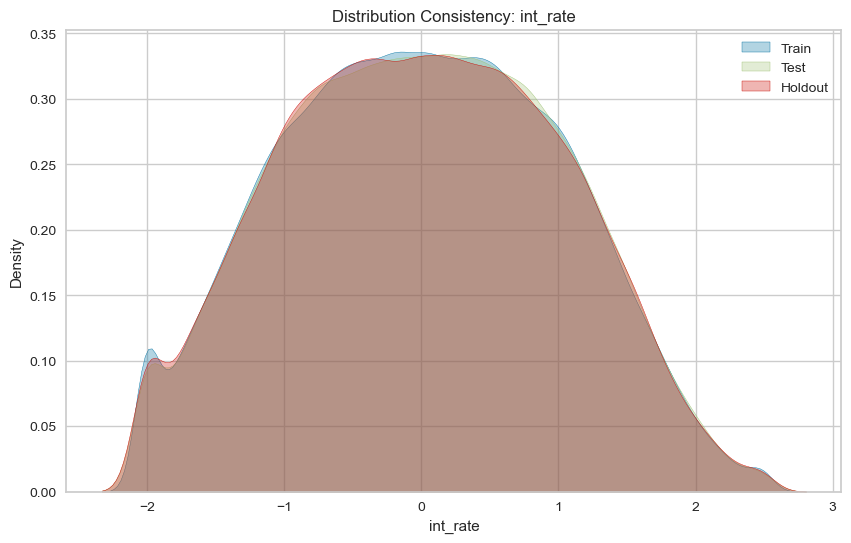

In [21]:
# Define a function that compares distributions of a feature across train, test, and holdout datasets
def plot_consistency(df_train, df_test, df_holdout, feature):
    plt.figure(figsize=(10, 6))
    # Plot the distribution (density curve) of the feature from the training, test and holdout set
    # fill=True → shade under the curve
    sns.kdeplot(df_train[feature], label='Train', fill=True, alpha=0.3)
    sns.kdeplot(df_test[feature], label='Test', fill=True, alpha=0.3)
    sns.kdeplot(df_holdout[feature], label='Holdout', fill=True, alpha=0.3)
    plt.title(f"Distribution Consistency: {feature}")
    plt.legend()
    plt.show()

# Numerical_columns[0] picks the first feature name from the list of numerical columns
plot_consistency(X_train_encoded, X_test_encoded, X_holdout_encoded, numerical_columns[0])

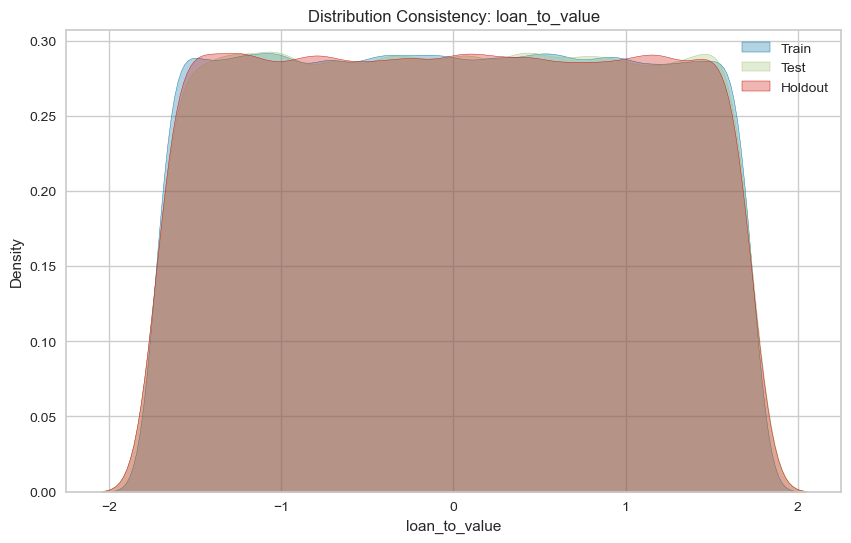

In [22]:
plot_consistency(X_train_encoded, X_test_encoded, X_holdout_encoded, numerical_columns[1])

In [23]:
X_train_encoded.head()

,int_rate,loan_to_value,interest_band_6.4-7.5,interest_band_7.5-9.5,interest_band_9.5-11.5,grade_B,grade_C,grade_D,collateral_Yes,regularity_of_inflows_Yes,ltv_group_Low,ltv_group_Moderate
0,-0.792745,0.226474,False,True,False,True,False,False,True,True,False,True
1,0.877013,0.758722,False,False,False,False,True,False,True,True,False,False
2,0.617476,-0.438907,False,False,True,False,True,False,True,True,True,False
3,1.017481,1.315611,False,False,False,False,True,False,True,True,False,False
4,-0.065171,-0.981044,False,False,True,True,False,False,False,True,True,False


# Checking for Class Imbalance in the Fully Preprocessed Dataset

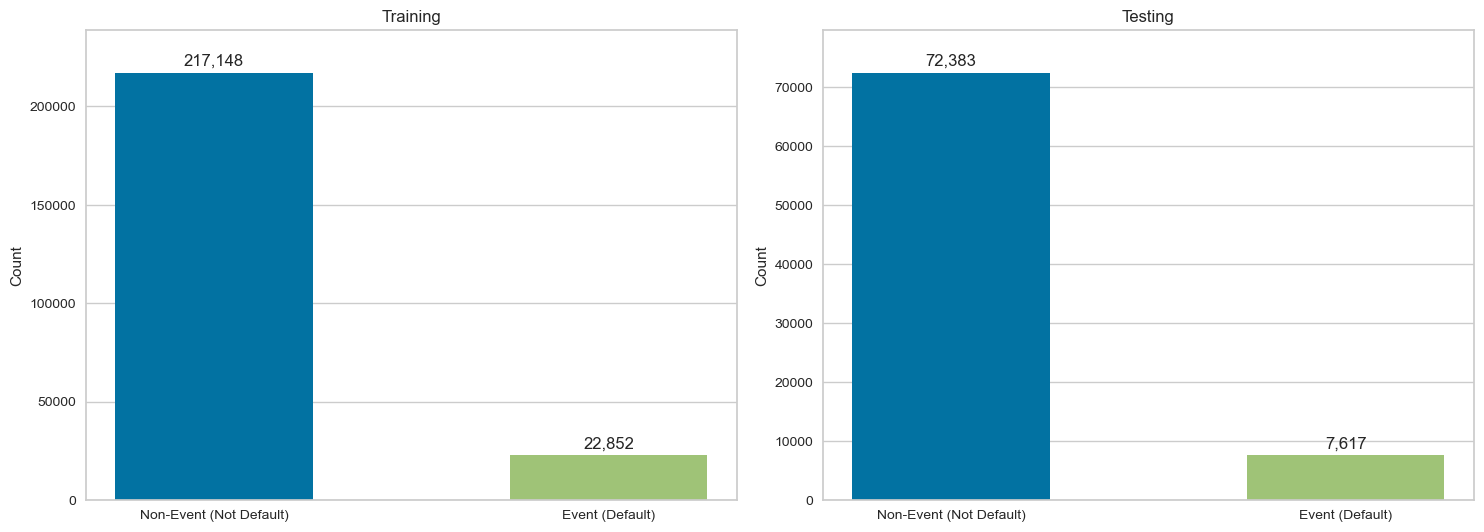

In [24]:
# Create 2 subplots side-by-side
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Define the sets and titles
datasets = [(y_train, "Training"), (y_test, "Testing")] #(y_holdout, "Holdout")

# Loop through each dataset and plot it
for i, (data, title) in enumerate(datasets):
    # Convert the target variable to a 1D array (required by ClassBalance to avoid errors)
    data_1d = data.values.ravel() 
    
    # Initialize visualizer
    visualizer = ClassBalance(labels=["Non-Event (Not Default)", "Event (Default)"], ax=axes[i])
    
    # Fit the data and draw the class distribution bars
    visualizer.fit(data_1d)
    
    # Finalize to map the text labels ("Non-Event", "Event") to the axis
    visualizer.finalize() 

    # Change the y-axis label to "Count" for clarity
    axes[i].set_ylabel("Count")
    
    # Add the actual count numbers on top of each bar
    for container in axes[i].containers:
        axes[i].bar_label(container, fmt='{:,.0f}', padding=3)
    
    axes[i].set_title(title)

# Add some extra padding at the top of the y-axis so the labels don't hit the ceiling
plt.tight_layout()
plt.subplots_adjust(top=0.85) 
plt.show()

From the chart above, we see the events classified as defaults have very few observations. This class imbalance can affect our model while training. To solve this problem, we will oversample the minority class.

# Oversampling Minority Class to Resolve Class Imbalance

In [ ]:
# Define strategies 
strategies = {
    "Original (Baseline)": None,
    "ADASYN": ADASYN(random_state=42),
    "SMOTE": SMOTE(random_state=42),
    "SMOTE-ENN": SMOTEENN(random_state=42),
    "ROS-Tomek": Pipeline([
        ('oversample', RandomOverSampler(random_state=42)),
        ('tomek', TomekLinks())])}

# Create an empty list to store results for each method
results = []

# Loop through each resampling method
for name, sampler in strategies.items():
    if sampler is not None:
        X_resample, y_resample = sampler.fit_resample(X_train_encoded, y_train)
    else:
        X_resample, y_resample = X_train_encoded, y_train
    
    # Train Logistic Regression model
    logit = LogisticRegression(max_iter=10000, random_state=42)
    logit.fit(X_resample, y_resample.values.ravel())
    
    # Get Probabilities
    y_pred_proba = logit.predict_proba(X_test_encoded)[:, 1]
    
    # Find optimal threshold using YOUDEN'S INDEX
    false_positive_rate, true_positive_rate, thresholds = roc_curve(y_test, y_pred_proba)

    # Youden's Index = TPR - FPR (same as Sensitivity + Specificity - 1)
    youden_index = true_positive_rate - false_positive_rate
    optimal_idx = np.argmax(youden_index)
    optimal_threshold = thresholds[optimal_idx]
    
    # Apply the method-specific optimal threshold
    y_pred = (y_pred_proba >= optimal_threshold).astype(int)
    
    # Store metrics
    results.append({
        "Method": name,
        "Optimal Threshold": round(optimal_threshold, 4),
        "Youden's Index": round(youden_index[optimal_idx], 4),
        "Test F1-Score": round(f1_score(y_test, y_pred), 4),
        "Test Recall": round(recall_score(y_test, y_pred), 4),
        "Test Precision": round(precision_score(y_test, y_pred), 4),
        "Train Size": len(y_resample),
        "Event Count (Train)": int((y_resample == 1).sum())
    })

# Convert to DataFrame and sort
comparison_df = pd.DataFrame(results)
order = list(strategies.keys())
comparison_df['Method'] = pd.Categorical(comparison_df['Method'], categories=order, ordered=True)
comparison_df = comparison_df.sort_values(by="Method")

# Display
print("🏦 BANK AUDIT: PERFORMANCE EVALUATED VIA YOUDEN'S INDEX (MAX SENSITIVITY + SPECIFICITY)")
print("-" * 110)
display(comparison_df.style.set_caption("Comparison of Resampling Methods at Optimal Youden Thresholds"))
        # Optional: .background_gradient(subset=['Test F1-Score', "Youden's Index"], cmap='YlGn'))

**Context and Final Recommendation**
Given the current macroeconomic environment—characterized by an economic downturn, sluggish growth, and heightened uncertainty due to the oil crisis—the bank faces elevated default risk and market volatility. In this context, the priority shifts toward maximizing the detection of bad debt, even at the expense of higher false positives.

**Final Verdict**: ADASYN
ADASYN is the preferred resampling method, delivering the strongest overall performance, albeit with only marginal improvement over alternatives.
- Highest F1-score (0.5424): Demonstrates the most effective balance between recall (identifying defaulters) and precision (limiting false positives).
- Highest Youden’s Index (0.7703): Indicates the best overall capability to distinguish between default and non-default cases.

**Key Performance Insights (Refer to PD model later)**
1. Recall (~93%) — Very High
- The model correctly identifies approximately 9 out of 10 defaulters
- Implies very few false negatives, meaning almost no high-risk customers go undetected
- Highly effective for risk mitigation and audit assurance
  
2. Precision (~38%) — Low
- Only about 4 out of 10 flagged customers actually default (A significant number of false positives, requiring additional review and potentially rejecting creditworthy customers)
- In practical terms, for every ~2.6 customers flagged as high-risk, only 1 truly defaults

3. F1-Score (~0.54) — Moderate
- Reflects the inherent trade-off: Strong recall is partially offset by lower precision

**Business Implications**
1. Positive Impact
- The model offers strong protection against credit losses by effectively identifying high-risk customers
- It significantly reduces the likelihood of undetected defaults (false negatives), which is especially critical during periods of economic stress

2. Trade-Off: A higher rate of false positives may result in:
- Rejection of creditworthy customers
- Increased operational costs due to additional manual reviews and risk assessments
- More frequent “false alarms,” which can negatively affect customer experience and potentially impact revenue growth

**Conclusion**
In a high-risk economic environment, a risk-averse strategy is both appropriate and justified. The model prioritizes minimizing false negatives (missed defaulters), aligning with the bank’s objective of protecting its loan portfolio. While this approach leads to a higher incidence of false positives, the trade-off is acceptable given the need to maintain financial stability during periods of elevated uncertainty.

In [ ]:
# Apply SMOTE to the Training data
# Used a random_state to ensure the results are reproducible every time it is executing
adasyn = ADASYN(random_state=42)
adasyn_features, adasyn_target = adasyn.fit_resample(X_train_encoded, y_train)

# Setup Visualization for "Before" vs "After"
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Prepare data for the loop (flattening to 1D to satisfy Yellowbrick)
plot_data = [
    (y_train.values.ravel(), "Training: Before ADASYN"),
    (adasyn_target.values.ravel(), "Training: After ADASYN (Balanced)")]

# Initialize the Yellowbrick ClassBalance visualizer with custom labels for the bars
for i, (data, title) in enumerate(plot_data):
    # Initialize visualizer
    visualizer = ClassBalance(labels=["Non-Event (Not Default)", "Event (Default)"], ax=axes[i])
    # Feed the data into the visualizer to calculate class frequencies
    visualizer.fit(data)
    # Clean up the formatting and apply the class labels to the chart axes
    visualizer.finalize() 
    # Set y-axis to 'Count' and add the data labels on top
    axes[i].set_ylabel("Count")

    # Add numeric labels on top of each bar for precise reading
    for container in axes[i].containers:
        axes[i].bar_label(container, fmt='{:,.0f}', padding=3)
    # Give each individual subplot its corresponding title  
    axes[i].set_title(title)

# Adjust layout to prevent overlapping and ensure everything fits nicely
plt.tight_layout()
plt.subplots_adjust(top=0.85) 
plt.show()

# Building PD Model

## Logistic Regression

In [ ]:
# Train the model using the ADASYN resampled features and target labels
logit = LogisticRegression(max_iter=10000, random_state=42)
logit.fit(adasyn_features, adasyn_target)

# Get the raw probability of the "Event" (Default) for the test set
# predict_proba returns [prob_of_0, prob_of_1]; selected index 1 for "Default"
# Skip y_pred = logit.predict(X_test_encoded) because it uses 0.5 by default. 
y_pred_proba = logit.predict_proba(X_test_encoded)[:, 1] # Probability of "Event"

# Calculate ROC Curve metrics
false_positive_rate, true_positive_rate, thresholds = roc_curve(y_test, y_pred_proba)
# Calculate Youden's J statistic: Sensitivity + Specificity - 1 or equivalent to TPR - FPR
youden_index = true_positive_rate - false_positive_rate
optimal_idx = np.argmax(youden_index)
optimal_threshold = thresholds[optimal_idx]

# Apply the manual threshold logic
y_pred = (y_pred_proba >= optimal_threshold).astype(int)

# Print the Classification Report to evaluate Precision and Recall
print(f"📝 Classification Report (Test Set - {optimal_threshold:.4f} Threshold):")
print(f"Optimal Threshold Found: {optimal_threshold:.4f}")
print(f"Maximized Youden's J: {youden_index[optimal_idx]:.4f}")
print(classification_report(y_test, y_pred, target_names=["Non-Event (Not Default)", "Event (Default)"], digits=4))

In [ ]:
# Create the figure and axis object
fig, ax = plt.subplots(figsize=(10, 6))

# Compute the confusion matrix values
cm = confusion_matrix(y_test, y_pred)

# Display confusion matrix with green color map
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm, 
    display_labels=["Non-Event (Not Default)", "Event (Default)"])

# Plot the matrix
disp.plot(cmap='Greens', ax=ax, colorbar=True)

# Remove default grid
ax.grid(False)

# Add clear borders around each cell
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.add_patch(
            plt.Rectangle(
                (j - 0.5, i - 0.5), 1, 1, fill=False, edgecolor='black', linewidth=1.5))

# Add strong outer border (spines)
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(2)       # thickness of border
    spine.set_edgecolor('black') # color of border

# Title and Formatting
plt.title(f"Confusion Matrix: Logistic Regression\n(Decision Threshold: {optimal_threshold:.4f})", 
          pad=20, fontsize=14, fontweight='bold')

# Add clear axis labels
plt.xlabel("Predicted Status", fontsize=12)
plt.ylabel("Actual Status", fontsize=12)
ax.tick_params(axis='both', which='both', length=0)
plt.tight_layout()
plt.show()

Visualize the trade-off between precision and recall, with particular focus on their intersection point. The approach is adapted from the methodology discussed in the following reference:
https://medium.com/@pacosun/precision-and-recall-are-fighting-for-your-models-soul-eef30a8a459c

In [ ]:
# Initialize the list to store results
results = []
name = "ADASYN"

# Get precision, recall, and thresholds from the model
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_proba)

# Find the threshold where Precision and Recall are closest to intersecting (the index where the absolute difference between them is minimal)
idx = np.argmin(np.abs(precision - recall))
intersection_threshold = thresholds[idx]
print(f"✨ Intersection Point Found at Threshold: {intersection_threshold:.4f}")

# Apply this specific threshold to create new predictions
y_pred_intersect = (y_pred_proba >= intersection_threshold).astype(int)

# Calculate final metrics at the intersection
current_f1 = f1_score(y_test, y_pred_intersect)
current_precision = precision[idx]
current_recall = recall[idx]

# Append results to the list (assuming 'results' and 'name' are defined earlier loop)
results.append({
    "Resampling Method": name,
    "Optimal Threshold": round(intersection_threshold, 4),
    "Precision Score": round(current_precision, 4),
    "Recall Score": round(current_recall, 4),
    "Final F1-Score": round(current_f1, 4)
})

# Create the figure and axis with a clean size
plt.figure(figsize=(10, 6))
# precision and recall have n+1 elements, so we slice them to match the thresholds array length
plt.plot(thresholds, precision[:-1], label="Precision", color='red', linewidth=2)
plt.plot(thresholds, recall[:-1], label="Recall", color='blue', linewidth=2)
# Add a vertical line at the chosen intersection threshold
plt.axvline(intersection_threshold, color='black', linestyle='--', label=f'Intersection ({intersection_threshold:.2f})')
# Set the tile and display
plt.title(f"Precision-Recall vs. Threshold ({name})")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# Display table
df_results = pd.DataFrame(results)
display(df_results)

In [ ]:
# Create a descriptive title that includes the threshold value
report_title = f"📊 Classification Report (Optimal Threshold: {intersection_threshold:.4f})"
print("\n" + "="*len(report_title))
print(report_title)
print("="*len(report_title))

# Generate the report
print(classification_report(y_test, y_pred_intersect, target_names=["Non-Event (Not Default)", "Event (Default)"], digits=4))

In [ ]:
# Calculate Sensitivity (TPR) and Specificity (1 - FPR)
false_positive_rate, true_positive_rate, thresholds = roc_curve(y_test, y_pred_proba)
specificity = 1 - false_positive_rate

# Compute Youden's J Index
youden_j = true_positive_rate + specificity - 1
optimal_idx = np.argmax(youden_j)
optimal_threshold = thresholds[optimal_idx]

# Calculate Accuracy
y_pred_optimal = (y_pred_proba >= optimal_threshold).astype(int)
optimal_accuracy = accuracy_score(y_test, y_pred_optimal)

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(thresholds, true_positive_rate, label="Sensitivity (TPR)", color='blue', linewidth=2)
plt.plot(thresholds, specificity, label="Specificity (TNR)", color='green', linewidth=2)
plt.axvline(optimal_threshold, color='red', linestyle='--', label=f'Optimal Threshold ({optimal_threshold:.4f})')
plt.title("Sensitivity vs. Specificity Trade-off")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# Calculate the Calculate ROC-AUC score (use y_pred_proba because AUC needs probabilities, not hard 0/1 predictions)
## AUC measures how well the model separates the two classes
auc_score = roc_auc_score(y_test, y_pred_proba)
## Print the AUC score (rounded to 4 decimal places)
print(f"🏆 ROC-AUC Score: {auc_score:.4f}")

# Compute values for ROC curve
## false_positive_rate → proportion of non-events incorrectly predicted as events
## true_positive_rate → proportion of actual events correctly identified (recall)
## thresholds → probability cut-offs used to compute these rates
false_positive_rate, true_positive_rate, thresholds = roc_curve(y_test, y_pred_proba)

# Create the plot
plt.figure(figsize=(10, 6))
# Plot the ROC curve
plt.plot(false_positive_rate, true_positive_rate, color='darkorange', lw=2, label=f'ROC curve (area = {auc_score:.4f})')
# Plot diagonal reference line (represents random guessing)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guess')
# Set axis limits
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
# Label axes clearly
plt.xlabel('False Positive Rate (Incorrectly Flagging Non-Events)')
plt.ylabel('True Positive Rate (Recall / Correctly Identifying Events)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

# GINI coefficient and CAP curve

The Gini Index is a measure used to evaluate the discriminatory power of a model, particularly in binary classification problems. It reflects how well the model can distinguish between classes (e.g., defaulters vs. non-defaulters).

---

**Conceptual Definition**
The Gini Index represents the "percentage of perfection" that a model achieves above a purely random baseline. 
- Random Model: Has zero discriminatory power (no better than a coin flip).
- Perfect Model: Separates all positive and negative cases without error.

**Mathematical Relationship**
The Gini Index is directly derived from the AUROC (Area Under the Receiver Operating Characteristic curve). While AUROC measures the total area under the curve, Gini measures the area between your model's curve and the random diagonal line.

$$Gini = 2 \times AUROC - 1$$

Interpretation Guide
The Gini Index typically ranges from 0 to 1. A higher value indicates a more predictive model.

| Gini Value | Interpretation |
| :--- | :--- |
| **0** | **No discrimination:** No better than random guessing. |
| **0.2 – 0.4** | **Weak:** Limited predictive signal. |
| **0.4 – 0.6** | **Moderate:** Practical value for risk ranking. |
| **0.6 – 0.8** | **Strong:** Good separation between classes. |
| **0.8 – 0.99** | **Very Strong:** Near-perfect discrimination. |
| **1.0** | **Perfect:** Rare in real-world data; usually indicates "data leakage." |

---

**Why Use Gini Instead of AUROC?**
While AUROC is the academic standard, the Gini Index is preferred in *Banking and Risk Management (e.g., Basel II/III compliance) for two main reasons:
1.  Intuitive Baseline: It directly communicates performance *above chance*. An AUROC of 0.5 is a "failure," but a Gini of 0 makes it immediately clear there is zero added value.
2.  Standardization: The 0–1 scale makes it easier for non-technical stakeholders to compare models (e.g., "Model A captures 60% of the available predictive power").

In [ ]:
# Derive the Gini Coefficient
gini_index = (2 * auc_score) - 1

In [ ]:
# Create a dictionary for the metrics
metrics_data = {
    "Metric": ["ROC-AUC Score", "Gini Index"],
    "Value": [round(auc_score, 4), round(gini_index, 4)]}

# Convert to a DataFrame for clean visualization
metrics_df = pd.DataFrame(metrics_data)

# Use display() to render the table nicely
print("📊 Model Discrimination Performance:")
display(metrics_df)

The Cumulative Accuracy Profile (CAP) curve is a visual tool used to show how well a model “captures” defaulters as you go through the population from highest predicted risk to lowest compared to a random guess and a "perfect" theoretical model.

**Axes**
- X‑axis – Percentage of total customers sampled (starting from the highest‑risk predictions).
- Y‑axis – Percentage of actual defaulters caught so far.

There are three lines on the chart:
1. Blue Dotted Line – Random Guess
- If you randomly pick customers, you catch defaulters at the same rate as you sample. E.g., picking 40% of customers catches ~40% of defaulters.

2. Green Line – Perfect Model
- An ideal model that catches all defaults by only looking at the smallest possible group of customers. It rises almost straight up to 100% very quickly.

3. Orange Line – Your Model (CAP Curve)
- How well your actual model performs. The closer it gets to the perfect line (green), the better.

In [ ]:
# Sort the probabilities in descending order and get indices (Highest risk customers come first)
sorted_index = np.argsort(y_pred_proba)[::-1]

# Convert y_test to NumPy array (avoids indexing issues)
y_test_array = np.array(y_test)
y_test_sorted = y_test_array[sorted_index]

# Calculate total positives (default) and population size
total_positives = np.sum(y_test_array)
total_population = len(y_test_array)
# Compute cumulative number of positives captured
cum_positives = np.cumsum(y_test_sorted)

# % of total defaults captured (X-axis)
perc_positives = cum_positives / total_positives
# % of population covered (y-axis)
perc_population = np.arange(1, total_population + 1) / total_population

# Add (0,0) for proper curve starting point
perc_positives = np.insert(perc_positives, 0, 0)
perc_population = np.insert(perc_population, 0, 0)

# Visualization
plt.figure(figsize=(10, 6))

# Random Guess model (diagonal line)
plt.plot([0, 1], [0, 1], color='navy', linestyle='--', label='Random Guess')

# Perfect model (captures all positives as early as possible)
perfect_x = [0, total_positives / total_population, 1]
perfect_y = [0, 1, 1]
plt.plot(perfect_x, perfect_y, color='green', linewidth=2, label='Perfect Model')

# Our model (CAP curve)
plt.plot(perc_population, perc_positives, color='darkorange', linewidth=2, label='Model CAP Curve')

# Formatting
plt.title('Cumulative Accuracy Profile (CAP) Curve', fontsize=14, fontweight='bold')
plt.xlabel('Proportion of Population Sampled (%)', fontsize=12)
plt.ylabel('Proportion of Defaults Captured (%)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend(loc='lower right')
plt.show()

In [ ]:
# Example: % defaults captured at top 20% population
top_20_idx = int(0.2 * total_population)
defaults_captured_20 = cum_positives[top_20_idx] / total_positives
print(f"Defaults captured in top 20%: {defaults_captured_20:.2%}")

In [ ]:
# 1. Calculate the Area Under the Model Curve (AUC-CAP)
# We use the trapezoidal rule to find the area under the orange line
area_model = np.trapz(perc_positives, perc_population)

# 2. Calculate the Area Under the Random Model (Diagonal)
# This is always 0.5 (area of a triangle with base 1 and height 1)
area_random = 0.5

# 3. Calculate the Area Under the Perfect Model
# This is the area under the green line
# Mathematically: 1 - 0.5 * (total_positives / total_population)
positive_rate = total_positives / total_population
area_perfect = 1 - 0.5 * positive_rate

# 4. Compute the Accuracy Ratio (AR)
# AR = (Area Model - Area Random) / (Area Perfect - Area Random)
accuracy_ratio = (area_model - area_random) / (area_perfect - area_random)

print(f"📈 CAP Accuracy Ratio (AR): {accuracy_ratio:.4f}")

**Performance Summary**
- Baseline: A random selection (diagonal line) would require sampling 50% of the data to find 50% of defaults.
- Model Efficiency: Our model (orange) captures approximately 90% of defaults within the first 20% of the sampled population.
- Conclusion: The model shows significant "lift" over the random baseline, making it highly effective for targeted intervention and risk mitigation.

The Kolmogorov-Smirnov (KS) curve is a visualization used to evaluate classification model performance by plotting the Cumulative Distribution Functions (CDFs) of two classes (e.g., defaulters vs. non-defaulters) against each other. The maximum vertical gap between these two curves is the KS statistic, which measures the model's ability to separate positive and negative classes.

In simpler words, KS curve focus on "At what point is the model best at separating the two groups?"

Source: https://towardsdatascience.com/kolmogorov-smirnov-statistic-explained-measuring-model-power-in-credit-risk-modeling/

| KS Statistic | Discriminatory Power | Business Context |
|-------------|----------------------|------------------|
| Below 0.20  | Poor                | The model lacks sufficient signal; no better than a very basic heuristic. |
| 0.20 – 0.40 | Fair                | Standard for many real-world applications; provides a useful but non-perfect signal. |
| 0.40 – 0.70 | Strong              | High degree of separation; highly effective signal. |
| Above 0.70  | Excellent           | Exceptional separation; check for potential data leakage or overfitting. |

In [ ]:
# Compute False Positive Rate (FPR) and True Positive Rate (TPR)
## TPR = cumulative % of events (defaults)
## FPR = cumulative % of non-events (non-defaults)
false_positive_rate, true_positive_rate, thresholds = roc_curve(y_test, y_pred_proba)

# Calculate KS statistic (KS is the maximum difference between TPR and FPR)
ks_distances = true_positive_rate - false_positive_rate
ks_statistic = np.max(ks_distances)
# Find the threshold where KS is maximized
ks_index = np.argmax(ks_distances)
ks_threshold = thresholds[ks_index]

# Plot TPR and FPR vs the Percentile of Population
plt.figure(figsize=(10, 6))
plt.plot(false_positive_rate, label='Cumulative Non-Events (FPR)', color='blue', lw=2)
plt.plot(true_positive_rate, label='Cumulative Events (TPR)', color='red', lw=2)

# Mark the KS Statistic (The vertical gap)
plt.vlines(x=ks_index, ymin=false_positive_rate[ks_index], ymax=true_positive_rate[ks_index], 
           colors='green', linestyles='--', lw=2, 
           label=f'KS Statistic: {ks_statistic:.4f}')

# Formatting
plt.title(f'Kolmogorov-Smirnov (KS) Curve\nMax Separation at Threshold: {ks_threshold:.4f}', fontsize=14, fontweight='bold')
plt.xlabel('Sorted Observations (Ranked by Risk)', fontsize=12)
plt.ylabel('Cumulative Proportion', fontsize=12)
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

In [ ]:
# Display the threshold and coefficients
print(f"📊 KS Coefficient: {ks_statistic:.4f}")
print(f"🎯 Optimal KS Threshold: {ks_threshold:.4f}")

# Applying PD model for decision making

When a model (like Logistic Regression) predicts credit risk, it doesn't initially give a score. It gives a Probability of Default (PD).Thereby, to make this useful, we will transform that decimal into a Credit Score using three main concepts:

---
**The Log-Odds**
- High Log-Odds = Very safe customer.
- Low Log-Odds = Very risky customer.

**The Scaling Logic (PDO)**
- Used to turn the Log-Odds into a human-friendly number

**Example:** If one customer's score is 600 and the PDO is 20, a person with a score of 620 is exactly twice as safe as that customer. A person with 640 is four times as safe.

---
**The Formula**
The final score is built using a simple linear equation:
$$Score = Offset + (Factor \times \ln(Odds))\ or\ Score = A - B \times \ln\left(\frac{PD}{1 - PD}\right)$$

* Offset: The starting point (the minimum baseline).
* Factor: How many points are awarded for each "unit" of risk reduction.
* $\ln(Odds)$: The specific risk level of the customer.

---
**Summary Table: UK Credit Rating (Experian methodology)**
| Score Range | Rating | Meaning |
| :--- | :--- | :--- |
| **961 – 999** | **Excellent** | Extremely low risk; highest chance of approval. |
| **881 – 960** | **Good** | Reliable customer; eligible for most competitive rates. |
| **721 – 880** | **Fair** | Moderate risk; may face higher interest rates. |
| **0 – 720** | **Poor** | High risk; likely to be declined or require a deposit. |

In [ ]:
def generate_credit_scorecard(y_proba, target_score=900, target_odds=50, pdo=20):
    """
    Transforms Probability of Default (PD) into a scaled Credit Score.
    The score is higher for lower risk (good customers) and lower for higher risk.
    Standard UK score range: 0-999.
    """
    # Calculate Scaling Factors
    factor = pdo / np.log(2)
    offset = target_score - (factor * np.log(target_odds))
    
    # Calculate Scores
    ## Convert PD to odds of "good" (non-default) vs "bad" (default)
    odds = (1 - y_proba) / y_proba
    scores = offset + (factor * np.log(odds))
    
    # Final scaled credit scores (UK Standard 0-999)
    credit_scores = np.clip(scores, 0, 999).astype(int)
    return credit_scores, factor, offset

In [ ]:
# Get probabilities of default for test set
y_pred_proba = logit.predict_proba(X_test_encoded)[:, 1]  # Probability of "Event"

# Generate credit scores
credit_scores, factor, offset = generate_credit_scorecard(y_proba=y_pred_proba, target_score=900, target_odds=50, pdo=20)

# Ensure y_test is 1D
y_test_1d = y_test.values.ravel() if hasattr(y_test, 'values') else np.array(y_test).ravel()

# Calculate average scores for each group
avg_non_default = credit_scores[y_test_1d == 0].mean()
avg_default = credit_scores[y_test_1d == 1].mean()

# Create summary DataFrame with 2 decimal places
summary = pd.DataFrame({
    'Group': ['Non-Defaulters', 'Defaulters'],
    'Average Credit Score': [f"{avg_non_default:.2f}", f"{avg_default:.2f}"], 
    'Number of Applicants': [len(credit_scores[y_test_1d == 0]), len(credit_scores[y_test_1d == 1])]})
display(summary)

In [ ]:
# We use y_pred_proba to determine the "Prediction" based on the optimal threshold found earlier
scoring_df = pd.DataFrame({
    'Probability_of_Default': y_pred_proba,
    'Credit_Score': credit_scores,
    'Prediction': ["Default" if p >= optimal_threshold else "Not Default" for p in y_pred_proba],
    'Actual_Status': ["Default" if a == 1 else "Not Default" for a in y_test_1d]
})

# Add a 'Rating' column for better business context (Optional but recommended)
def get_rating(score):
    if score >= 961: return "Excellent"
    if score >= 881: return "Good"
    if score >= 721: return "Fair"
    return "Poor"

scoring_df['Rating'] = scoring_df['Credit_Score'].apply(get_rating)

# Quick Accuracy Check
correct_preds = (scoring_df['Prediction'] == scoring_df['Actual_Status']).sum()
accuracy = (correct_preds / len(scoring_df)) * 100
print(f"✅ Prediction Accuracy on Test Set: {accuracy:.2f}%")

# Display the result
print("📊 Sample of Credit Scores based on PD Model:")
display(scoring_df.head(10))

In [ ]:
def explain_individual_score(model, X_row, sample_pd, final_score, factor, offset=None, threshold=optimal_threshold):
    """
    Shows how each feature contributed to the final credit score.
    - Positive impact (green) → increases credit score (good)
    - Negative impact (red)   → decreases credit score (bad)
    """
    # --- Determine rating from final score ---
    if final_score >= 961:
        rating = "Excellent"
        rating_color = "#4ade80"      # bright green
    elif final_score >= 881:
        rating = "Good"
        rating_color = "#86efac"      # lighter green
    elif final_score >= 721:
        rating = "Fair"
        rating_color = "#facc15"      # yellow
    else:  # 0 – 720
        rating = "Poor"
        rating_color = "#fb7185"      # soft red

    # --- Determine default prediction based on probability threshold ---
    is_default = sample_pd >= threshold
    prediction_text = "Default" if is_default else "Not Default"
    prediction_color = "#fb7185" if is_default else "#4ade80"  # red for default, green for non-default

    # --- Get feature names and coefficients ---
    feature_names = X_row.index
    coefficients = model.coef_[0]   # assumes binary classification
    # Store feature contributions
    breakdown = []

    # Loop through each feature
    for name, coef, val in zip(feature_names, coefficients, X_row):
        # Calculate contribution to score
        # Negative sign: higher coefficient → higher PD → lower credit score
        points = -(coef * val) * factor
        
        # Determine if feature helps or hurts score
        if points > 0:
            impact_type = '✅ Positive'
        elif points < 0:
            impact_type = '❌ Negative'
        else:
            impact_type = '⚪ No Impact'
        
        # Format feature value for display
        if isinstance(val, (bool, np.bool_)):
            val_display = int(val)
        else:
            val_display = round(val, 4)

        # Store results
        breakdown.append({
            'Feature': name,
            'Value': val_display,
            'Point Impact': round(points, 2),
            'Impact Type': impact_type})

    # Convert results to DataFrame
    df_breakdown = pd.DataFrame(breakdown)
    
    # --- Dark mode friendly visualisation ---
    display(HTML(f"""
        <div style="border: 2px solid #4ade80; padding: 20px; background-color: #1a1a1a; border-radius: 10px; margin-bottom: 20px; font-family: sans-serif;">
            <h2 style="margin: 0; color: #4ade80; letter-spacing: 1px;">CREDIT SCORE AUDIT</h2>
            <p style="font-size: 18px; color: #ffffff; margin: 10px 0 5px 0;">
                Final Score: <b style="color: #60a5fa; font-size: 26px;">{final_score}</b>
                &nbsp;&nbsp;|&nbsp;&nbsp;
                <span style="background-color: {rating_color}; color: #0f172a; padding: 4px 12px; border-radius: 20px; font-weight: bold;">{rating}</span>
            </p>
            <p style="color: #9ca3af; margin: 0;">
                Prob. of Default: <b style="color: #f87171;">{sample_pd:.4%}</b>
                &nbsp;&nbsp;|&nbsp;&nbsp;
                Prediction: <b style="color: {prediction_color};">{prediction_text}</b>
            </p>
        </div>"""))
    
    # Function to color rows based on Sentiment column
    def style_sentiment(row):
        if '✅' in str(row['Impact Type']):
            return ['color: #4ade80; font-weight: bold'] * len(row)
        elif '❌' in str(row['Impact Type']):
            return ['color: #fb7185; font-weight: bold'] * len(row)
        return ['color: #d1d5db'] * len(row)
    
    styled_df = df_breakdown.style.apply(style_sentiment, axis=1)\
        .format({"Point Impact": "{:+.2f}"})\
        .set_table_styles([
            {'selector': 'th', 'props': [('background-color', '#334155'), ('color', '#f8fafc'), ('text-align', 'left')]},
            {'selector': 'table', 'props': [('border-collapse', 'collapse'), ('width', '100%'), ('background-color', '#0f172a')]},
            {'selector': 'td', 'props': [('border', '1px solid #1e293b'), ('padding', '8px')]}
        ])
    display(styled_df)

In [ ]:
# Test the function for a specific customer
explain_individual_score(model=logit, 
                         X_row=X_test_encoded.iloc[39308], 
                         sample_pd=y_pred_proba[39308],
                         final_score=credit_scores[39308], 
                         factor=factor, offset=offset, threshold=optimal_threshold)

# Credit Score visualization

In [ ]:
# --- 1. Data Preparation & Light-Theme Synchronization ---
# Using a clean white grid style
plt.style.use('seaborn-v0_8-whitegrid') 

# Create order and light-theme colors setting
rating_order = ["Poor", "Fair", "Good", "Excellent"]
experian_colors = ['#d9534f', '#f0ad4e', '#5bc0de', '#5cb85c'] 
color_map = dict(zip(rating_order, experian_colors))

# Ensure Categorical ordering
scoring_df['Rating'] = pd.Categorical(scoring_df['Rating'], categories=rating_order, ordered=True)

# Calculate Feature Contributions
factor_val = 40 / np.log(2) 
contrib_df = pd.DataFrame({
    'Feature': X_test_encoded.columns,
    'Average_Contribution': -(logit.coef_[0] * factor_val)
})
top_risk_features = contrib_df.nsmallest(10, 'Average_Contribution').sort_values('Average_Contribution')

# --- 2. Initialize Dashboard with White/Light Background ---
fig, axes = plt.subplots(2, 2, figsize=(20, 14), facecolor='#ffffff')
plt.subplots_adjust(hspace=0.35, wspace=0.25)

# Helper function to style each axis for light theme clarity
def style_axis_light(ax, title, title_color):
    ax.set_facecolor('#fdfdfd') 
    ax.set_title(title, fontsize=16, fontweight='bold', color=title_color, pad=15)
    ax.tick_params(colors='#333333', labelsize=11)
    ax.xaxis.label.set_color('#555555')
    ax.yaxis.label.set_color('#555555')
    # Set border (spines) colors
    for spine in ax.spines.values():
        spine.set_edgecolor('#cccccc')
        spine.set_visible(True)
    ax.grid(True, linestyle=':', alpha=0.6, color='#888888')

# --- PLOT 1: Top 10 Risk Drivers (Top Left) ---
sns.barplot(data=top_risk_features, y='Feature', x='Average_Contribution', 
            ax=axes[0, 0], palette='Reds_r') # Classic Red gradient for risk
style_axis_light(axes[0, 0], 'TOP 10 RISK DRIVERS (POINT DEDUCTIONS)', '#c9302c')
axes[0, 0].set_xlabel('Score Impact (Points)')

# --- PLOT 2: Credit Score vs PD Probability (Top Right) ---
sns.scatterplot(data=scoring_df, x='Probability_of_Default', y='Credit_Score', 
                hue='Rating', ax=axes[0, 1], palette=color_map, alpha=0.6, s=70, edgecolor='#ffffff', linewidth=0.8)
style_axis_light(axes[0, 1], 'SCORE VS. PROBABILITY OF DEFAULT', '#204d74')
axes[0, 1].legend(title='Rating Tier', loc='upper right', frameon=True, facecolor='white', edgecolor='#cccccc')

# --- PLOT 3: Customer Count by Rating Tier (Bottom Left) ---
rating_counts = scoring_df['Rating'].value_counts().reindex(rating_order)
sns.barplot(x=rating_counts.index, y=rating_counts.values, ax=axes[1, 0], palette=experian_colors, edgecolor='#555555')
style_axis_light(axes[1, 0], 'PORTFOLIO VOLUME BY RATING', '#31708f')

# Add dark labels on top of bars for readability on light background
for p in axes[1, 0].patches:
    axes[1, 0].annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', xytext=(0, 10), textcoords='offset points', color='#333333', fontweight='bold', fontsize=12)

# --- PLOT 4: Score Distribution & Thresholds (Bottom Right) ---
sns.histplot(scoring_df['Credit_Score'], bins=10, kde=True, ax=axes[1, 1], color='#337ab7', alpha=0.3, edgecolor='#2e6da4')
axes[1, 1].axvline(881, color='#ec971f', linestyle='--', linewidth=2, label='Good Threshold (881)')
axes[1, 1].axvline(961, color='#449d44', linestyle='--', linewidth=2, label='Excellent Threshold (961)')
style_axis_light(axes[1, 1], 'OVERALL SCORE DISTRIBUTION', '#2e6da4')
axes[1, 1].legend(facecolor='white', edgecolor='#cccccc')

# Final Super Title
plt.suptitle('Credit Risk Model Performance & Scorecard Dashboard', fontsize=24, y=0.98, color='#222222', fontweight='black')

plt.show()

# Test on Holdout set

**Holdout Validation Strategy**
To ensure the model generalizes to unseen data, we applied the `optimal_threshold` derived from the test set to the holdout set. 

**Key findings:**
* The performance is consistent with the test set, the model is robust.

In [ ]:
# Get probabilities for the holdout set
y_holdout_proba = logit.predict_proba(X_holdout_encoded)[:, 1]

# Apply the PREVIOUSLY FOUND optimal_threshold from the test set
y_holdout_pred = (y_holdout_proba >= optimal_threshold).astype(int)

# Print the Evaluation
print(f"📝 Holdout Set Evaluation (Using Test Threshold: {optimal_threshold:.4f}):")
print(classification_report(y_holdout, y_holdout_pred, target_names=["Non-Event (Not Default)", "Event (Default)"], digits=4))

In [ ]:
# Create the figure and axis object
fig, ax = plt.subplots(figsize=(10, 6))

# Compute the confusion matrix values
cm_holdout = confusion_matrix(y_holdout, y_holdout_pred)

# Display confusion matrix with green color map
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_holdout, 
    display_labels=["Non-Event (Not Default)", "Event (Default)"])

# Plot the matrix
disp.plot(cmap='Greens', ax=ax, colorbar=True)

# Remove default grid
ax.grid(False)

# Add clear borders around each cell
for i in range(cm_holdout.shape[0]):
    for j in range(cm_holdout.shape[1]):
        ax.add_patch(
            plt.Rectangle(
                (j - 0.5, i - 0.5), 1, 1, fill=False, edgecolor='black', linewidth=1.5))

# Add strong outer border (spines)
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(2)
    spine.set_edgecolor('black')

# Title and Formatting
plt.title(f"Confusion Matrix: Holdout Set Evaluation\n(Threshold Fixed at: {optimal_threshold:.4f})", 
          pad=20, fontsize=14, fontweight='bold')

# Add clear axis labels
plt.xlabel("Predicted Status", fontsize=12)
plt.ylabel("Actual Status", fontsize=12)
ax.tick_params(axis='both', which='both', length=0)

plt.tight_layout()
plt.show()

In [ ]:
# Calculate the Calculate ROC-AUC score 
auc_score = roc_auc_score(y_holdout, y_holdout_proba)
## Print the AUC score (rounded to 4 decimal places)
print(f"🏆 ROC-AUC Score: {auc_score:.4f}")

# Compute values for ROC curve
false_positive_rate, true_positive_rate, thresholds = roc_curve(y_holdout, y_holdout_proba)

# Create the plot
plt.figure(figsize=(10, 6))
# Plot the ROC curve
plt.plot(false_positive_rate, true_positive_rate, color='darkorange', lw=2, label=f'ROC curve (area = {auc_score:.4f})')
# Plot diagonal reference line (represents random guessing)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guess')
# Set axis limits
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
# Label axes clearly
plt.xlabel('False Positive Rate (Incorrectly Flagging Non-Events)')
plt.ylabel('True Positive Rate (Recall / Correctly Identifying Events)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

In [ ]:
# Derive the Gini Coefficient
gini_index = (2 * auc_score) - 1

# Create a dictionary for the metrics
metrics_data = {
    "Metric": ["ROC-AUC Score", "Gini Index"],
    "Value": [round(auc_score, 4), round(gini_index, 4)]}

# Convert to a DataFrame for clean visualization
metrics_df = pd.DataFrame(metrics_data)

# Use display() to render the table nicely
print("📊 Model Discrimination Performance:")
display(metrics_df)

In [ ]:
# Get probabilities of default for holdout set
y_holdout_proba = logit.predict_proba(X_holdout_encoded)[:, 1]  # Probability of "Event"

# Generate credit scores
credit_scores, factor, offset = generate_credit_scorecard(y_proba=y_holdout_proba, target_score=900, target_odds=50, pdo=20)

# Ensure y_holdout is 1D
y_holdout_1d = y_holdout.values.ravel() if hasattr(y_holdout, 'values') else np.array(y_holdout).ravel()

# Calculate average scores for each group
avg_non_default = credit_scores[y_holdout_1d == 0].mean()
avg_default = credit_scores[y_holdout_1d == 1].mean()

# Create summary DataFrame with 2 decimal places
summary = pd.DataFrame({
    'Group': ['Non-Defaulters', 'Defaulters'],
    'Average Credit Score': [f"{avg_non_default:.2f}", f"{avg_default:.2f}"], 
    'Number of Applicants': [len(credit_scores[y_holdout_1d == 0]), len(credit_scores[y_holdout_1d == 1])]})
display(summary)

In [ ]:
# We use y_holdout_proba to determine the "Prediction" based on the optimal threshold found earlier
scoring_df = pd.DataFrame({
    'Probability_of_Default': y_holdout_proba,
    'Credit_Score': credit_scores,
    'Prediction': ["Default" if p >= optimal_threshold else "Not Default" for p in y_holdout_proba],
    'Actual_Status': ["Default" if a == 1 else "Not Default" for a in y_holdout_1d]
})

# Add a 'Rating' column for better business context (Optional but recommended)
def get_rating(score):
    if score >= 961: return "Excellent"
    if score >= 881: return "Good"
    if score >= 721: return "Fair"
    return "Poor"

scoring_df['Rating'] = scoring_df['Credit_Score'].apply(get_rating)

# Quick Accuracy Check
correct_preds = (scoring_df['Prediction'] == scoring_df['Actual_Status']).sum()
accuracy = (correct_preds / len(scoring_df)) * 100
print(f"✅ Prediction Accuracy on Holdout Set: {accuracy:.2f}%")

# Display the result
print("📊 Sample of Credit Scores based on PD Model:")
display(scoring_df.head(10))

In [ ]:
# Test the function for a specific customer
explain_individual_score(model=logit, 
                         X_row=X_holdout_encoded.iloc[39308], 
                         sample_pd=y_holdout_proba[39308],
                         final_score=credit_scores[39308], 
                         factor=factor, offset=offset, threshold=optimal_threshold)

# Saving model and notebook

In [ ]:
# Create a dedicated folder for the models if it doesn't exist
target_directory = r"C:\Users\danie\Downloads\Data Analytic\credit_loan_analysis\models"
if not os.path.exists(target_directory):
    os.makedirs(target_directory)
    print(f"✅ Created directory: {target_directory}")
else:
    print(f"📂 Directory already exists: {target_directory}")

# Define the full file path for the model and csv
model_path = os.path.join(target_directory, "credit_risk_pd_model.pkl")
results_path = os.path.join(target_directory, "final_scoring_results.csv")

# Consolidate model, scaling factors, and feature names
model_data = {
    "model": logit,
    "factor": factor,
    "offset": offset,
    "optimal_threshold": optimal_threshold,
    "feature_names": X_test_encoded.columns.tolist()}

scoring_df = scoring_df.reset_index(drop=True)
# Save using Pickle
try:
    with open(model_path, 'wb') as file:
        pickle.dump(model_data, file)
    print(f"🚀 Success! Model saved to:\n{model_path}")
except Exception as e:
    print(f"❌ An error occurred while saving: {e}")

# Save the Results using CSV
try:
    scoring_df.to_csv(results_path, index=False)
    print(f"📊 Success! Scoring results CSV saved to:\n{results_path}")
except Exception as e:
    print(f"❌ An error occurred while saving the CSV: {e}")

In [ ]:
import shutil

# Define source and destination
current_notebook_name = "credit_risk_PD_model.ipynb" 
destination_path = r"C:\Users\danie\Downloads\Data Analytic\credit_loan_analysis\models"

# Ensure destination exists
if not os.path.exists(destination_path):
    os.makedirs(destination_path)

# Perform the copy
try:
    # This looks for the file in the current working directory
    shutil.copy(current_notebook_name, os.path.join(destination_path, current_notebook_name))
    print(f"✅ Notebook successfully copied to: {destination_path}")
except FileNotFoundError:
    print(f"❌ Error: Could not find '{current_notebook_name}'.")
    print("👉 Make sure the filename matches exactly and you have saved (Ctrl+S) recently.")
except Exception as e:
    print(f"❌ An unexpected error occurred: {e}")

# Future Scope

- In this part, only the white-box PD model is built. We used logistic regression which is explainable by p-values of the features.
- In next part, we will build some black-box PD models (non-explainable) and will use different libraries to know important features for model explainability.